# Instagram Data Analysis — Alfido Tech

This notebook analyzes the supplied Instagram-style export for engagement, content types, hashtags, posting schedule, and follower-growth signals.

**Important data-quality note:** the supplied export has a single timestamp (`13-04-2023 08:04`) for all 257 posts and all 7,623 follow records. Therefore, the notebook does **not** claim a data-derived best day/hour or historical follower-growth trend. Instead, it identifies what the export supports and proposes a testable posting calendar.


In [1]:
photos = pd.read_csv("data/photos.csv")
likes = pd.read_csv("data/likes.csv")
comments = pd.read_csv("data/comments.csv")
follows = pd.read_csv("data/follows.csv")
photo_tags = pd.read_csv("data/photo_tags.csv")
tags = pd.read_csv("data/tags.csv")
users = pd.read_csv("data/users.csv")

NameError: name 'pd' is not defined

In [2]:
import pandas as pd

In [4]:
photos = pd.read_csv("data/photos.csv")
likes = pd.read_csv("data/likes.csv")
comments = pd.read_csv("data/comments.csv")
follows = pd.read_csv("data/follows.csv")
photo_tags = pd.read_csv("data/photo_tags.csv")
tags = pd.read_csv("data/tags.csv")
users = pd.read_csv("data/users.csv")

print(photos.head())
print(likes.head())
print(comments.head())
print(follows.head())
print(photo_tags.head())
print(tags.head())
print(users.head())

   id            image link  user ID       created dat Insta filter used  \
0   1     http://elijah.biz        1  13-04-2023 08:04               yes   
1   2    https://shanon.org        1  13-04-2023 08:04                no   
2   3      http://vicky.biz        1  13-04-2023 08:04                no   
3   4      http://oleta.net        1  13-04-2023 08:04                no   
4   5  https://jennings.biz        1  13-04-2023 08:04               yes   

  photo type  
0      photo  
1      photo  
2      photo  
3      photo  
4      photo  
   user   photo      created time following or not    like type
0      2      1  13-04-2023 08:04              yes  heart emoji
1      2      4  13-04-2023 08:04               no    thumbs up
2      2      8  13-04-2023 08:04              yes     laughing
3      2      9  13-04-2023 08:04               no         fire
4      2     10  13-04-2023 08:04              yes         clap
   id                 comment  User  id  Photo id created Timestamp  

In [6]:
print("Photos:", photos.shape)
print("Likes:", likes.shape)
print("Comments:", comments.shape)
print("Follows:", follows.shape)
print("Photo Tags:", photo_tags.shape)
print("Tags:", tags.shape)
print("Users:", users.shape)

Photos: (257, 6)
Likes: (8782, 5)
Comments: (7488, 8)
Follows: (7623, 5)
Photo Tags: (501, 3)
Tags: (21, 4)
Users: (100, 6)


In [8]:
print(photos.columns)
print(likes.columns)
print(comments.columns)
print(follows.columns)
print(photo_tags.columns)
print(tags.columns)
print(users.columns)

Index(['id', 'image link', 'user ID', 'created dat', 'Insta filter used',
       'photo type'],
      dtype='str')
Index(['user ', 'photo', 'created time', 'following or not', 'like type'], dtype='str')
Index(['id', 'comment', 'User  id', 'Photo id', 'created Timestamp',
       'posted date', 'emoji used', 'Hashtags used count'],
      dtype='str')
Index(['follower', 'followee ', 'created time', 'is follower active',
       'followee Acc status'],
      dtype='str')
Index(['photo', 'tag ID', 'user id'], dtype='str')
Index(['id', 'tag text', 'created time', 'location'], dtype='str')
Index(['id', 'name', 'created time', 'private/public', 'post count',
       'Verified status'],
      dtype='str')


In [9]:
photos.info()

<class 'pandas.DataFrame'>
RangeIndex: 257 entries, 0 to 256
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 257 non-null    int64
 1   image link         257 non-null    str  
 2   user ID            257 non-null    int64
 3   created dat        257 non-null    str  
 4   Insta filter used  257 non-null    str  
 5   photo type         257 non-null    str  
dtypes: int64(2), str(4)
memory usage: 12.2 KB


In [10]:
photos.describe(include="all")

,id,image link,user ID,created dat,Insta filter used,photo type
count,257.000000,257,257.000000,257,257,257
unique,NaN,257,NaN,1,2,3
top,NaN,http://elijah.biz,NaN,13-04-2023 08:04,yes,photo
freq,NaN,1,NaN,257,142,155
mean,129.000000,NaN,47.330739,NaN,NaN,NaN
std,74.333707,NaN,29.475817,NaN,NaN,NaN
min,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,65.000000,NaN,23.000000,NaN,NaN,NaN
50%,129.000000,NaN,47.000000,NaN,NaN,NaN
75%,193.000000,NaN,72.000000,NaN,NaN,NaN


In [11]:
photos["created_date"] = pd.to_datetime(
    photos["created dat"],
    dayfirst=True,
    errors="coerce"
)

In [12]:
likes["created_date"] = pd.to_datetime(
    likes["created time"],
    dayfirst=True,
    errors="coerce"
)

In [13]:
comments["created_date"] = pd.to_datetime(
    comments["created Timestamp"],
    dayfirst=True,
    errors="coerce"
)

In [14]:
follows["created_date"] = pd.to_datetime(
    follows["created time"],
    dayfirst=True,
    errors="coerce"
)

In [15]:
print(photos["created_date"].isna().sum())

0


In [16]:
print(photos["created_date"].nunique())

1


In [17]:
print(photos["created_date"].unique())

<DatetimeArray>
['2023-04-13 08:04:00']
Length: 1, dtype: datetime64[us]


In [18]:
likes_per_post = likes.groupby("photo").size()

likes_per_post.head()

photo
1    25
2    36
3    38
4    38
5    31
dtype: int64

In [19]:
likes_per_post = likes_per_post.rename("likes")

In [20]:
comments_per_post = comments.groupby("Photo id").size()

comments_per_post = comments_per_post.rename("comments")

In [21]:
post_data = photos[
    ["id", "user ID", "created_date", "photo type", "Insta filter used"]
].copy()

In [22]:
post_data = post_data.join(
    likes_per_post,
    on="id"
)

In [23]:
post_data = post_data.join(
    comments_per_post,
    on="id"
)

In [24]:
post_data["likes"] = post_data["likes"].fillna(0)
post_data["comments"] = post_data["comments"].fillna(0)

In [25]:
post_data["engagement"] = (
    post_data["likes"] +
    post_data["comments"]
)

In [26]:
followers = (
    follows
    .groupby("followee ")
    ["follower"]
    .nunique()
)

In [27]:
followers = followers.rename("followers")

In [28]:
post_data = post_data.merge(
    followers,
    left_on="user ID",
    right_index=True,
    how="left"
)

In [29]:
post_data["followers"] = post_data["followers"].fillna(0)

In [30]:
post_data["engagement_rate"] = (
    post_data["engagement"] /
    post_data["followers"]
)

In [32]:
post_data.head()

,id,user ID,created_date,photo type,Insta filter used,likes,comments,engagement,followers,engagement_rate
0,1,1,2023-04-13 08:04:00,photo,yes,25,25,50,77,0.649351
1,2,1,2023-04-13 08:04:00,photo,no,36,31,67,77,0.870130
2,3,1,2023-04-13 08:04:00,photo,no,38,27,65,77,0.844156
3,4,1,2023-04-13 08:04:00,photo,no,38,32,70,77,0.909091
4,5,1,2023-04-13 08:04:00,photo,yes,31,27,58,77,0.753247


In [33]:
top_posts = post_data.sort_values(
    "engagement_rate",
    ascending=False
)

top_posts.head(10)

,id,user ID,created_date,photo type,Insta filter used,likes,comments,engagement,followers,engagement_rate
12,13,3,2023-04-13 08:04:00,photo,no,40,39,79,76,1.039474
144,145,52,2023-04-13 08:04:00,video,yes,48,27,75,76,0.986842
146,147,55,2023-04-13 08:04:00,photo,no,41,34,75,76,0.986842
117,118,43,2023-04-13 08:04:00,photo,yes,39,35,74,76,0.973684
226,227,87,2023-04-13 08:04:00,photo,no,39,35,74,76,0.973684
224,225,87,2023-04-13 08:04:00,video,no,37,36,73,76,0.960526
195,196,73,2023-04-13 08:04:00,photo,yes,38,35,73,76,0.960526
122,123,44,2023-04-13 08:04:00,photo,yes,42,31,73,76,0.960526
126,127,46,2023-04-13 08:04:00,photo,yes,43,30,73,76,0.960526
96,97,32,2023-04-13 08:04:00,photo,yes,40,32,72,76,0.947368


In [34]:
post_data["photo type"].value_counts()

photo type
photo       155
video        52
carousel     50
Name: count, dtype: int64

In [35]:
content_analysis = (
    post_data
    .groupby("photo type")
    .agg(
        posts=("id", "count"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_engagement=("engagement", "mean"),
        avg_engagement_rate=("engagement_rate", "mean")
    )
)

In [36]:
content_analysis

,posts,avg_likes,avg_comments,avg_engagement,avg_engagement_rate
photo type,,,,,
carousel,50,33.860000,28.680000,62.540000,0.819945
photo,155,34.387097,29.245161,63.632258,0.833777
video,52,33.826923,29.250000,63.076923,0.826890


NameError: name 'plt' is not defined

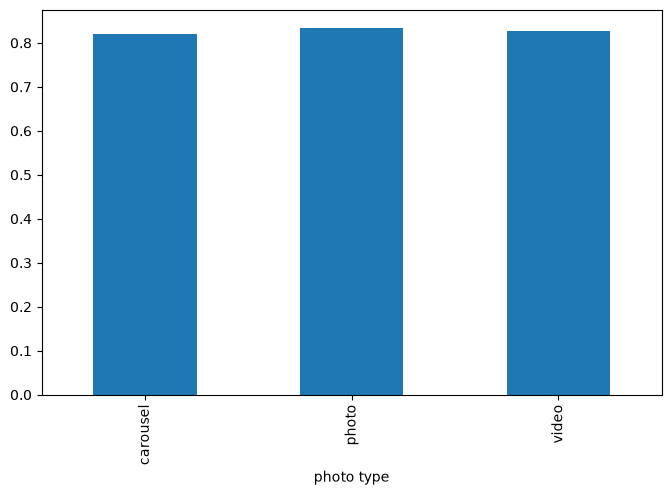

In [37]:
content_analysis["avg_engagement_rate"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Engagement Rate by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=0)
plt.show()

In [38]:
import matplotlib.pyplot as plt

In [40]:
tag_data = photo_tags.merge(
    tags[["id", "tag text"]],
    left_on="tag ID",
    right_on="id",
    how="left"
)

In [41]:
tag_data = tag_data.merge(
    post_data,
    left_on="photo",
    right_on="id",
    how="left"
)

In [42]:
hashtag_analysis = (
    tag_data
    .groupby("tag text")
    .agg(
        posts=("photo", "nunique"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_engagement_rate=("engagement_rate", "mean")
    )
    .sort_values(
        "avg_engagement_rate",
        ascending=False
    )
)

In [43]:
reliable_hashtags = hashtag_analysis[
    hashtag_analysis["posts"] >= 10
]

In [44]:
reliable_hashtags.head(10)

,posts,avg_likes,avg_comments,avg_engagement_rate
tag text,,,,
delicious,15,34.933333,30.333333,0.857428
beauty,20,34.950000,30.200000,0.854007
foodie,11,34.727273,29.909091,0.848506
sunset,19,34.210526,30.210526,0.843104
stunning,16,34.937500,29.312500,0.842714
food,24,33.833333,30.291667,0.841671
photography,16,34.500000,29.500000,0.838015
dreamy,20,35.750000,28.150000,0.837662
smile,59,34.457627,29.237288,0.834621


In [45]:
likes["following or not"].value_counts()

following or not
yes    5853
no     2929
Name: count, dtype: int64

In [46]:
likes["following or not"].value_counts(
    normalize=True
) * 100

following or not
yes    66.647688
no     33.352312
Name: proportion, dtype: float64

In [47]:
post_data["hour"] = post_data["created_date"].dt.hour
post_data["day"] = post_data["created_date"].dt.day_name()

In [48]:
hour_analysis = (
    post_data
    .groupby("hour")["engagement_rate"]
    .mean()
)

In [49]:
day_analysis = (
    post_data
    .groupby("day")["engagement_rate"]
    .mean()
)

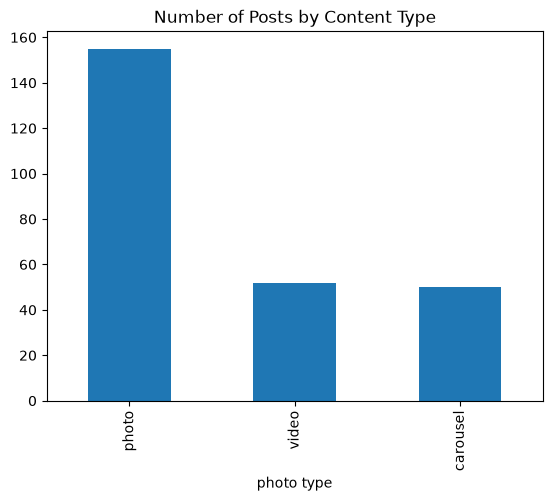

In [50]:
post_data["photo type"].value_counts().plot(
    kind="bar"
)

plt.title("Number of Posts by Content Type")
plt.show()

## 1. Setup and data loading

Expected files: `comments.csv`, `follows.csv`, `likes.csv`, `photo_tags.csv`, `photos.csv`, `tags.csv`, `users.csv` in `instagram_export/`.


In [55]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path('instagram_export')
photos = pd.read_csv(DATA_DIR/'photos.csv')
likes = pd.read_csv(DATA_DIR/'likes.csv')
comments = pd.read_csv(DATA_DIR/'comments.csv')
follows = pd.read_csv(DATA_DIR/'follows.csv')
photo_tags = pd.read_csv(DATA_DIR/'photo_tags.csv')
tags = pd.read_csv(DATA_DIR/'tags.csv')
users = pd.read_csv(DATA_DIR/'users.csv')

photos['dt'] = pd.to_datetime(photos['created dat'], dayfirst=True, errors='coerce')
likes['dt'] = pd.to_datetime(likes['created time'], dayfirst=True, errors='coerce')
comments['dt'] = pd.to_datetime(comments['created Timestamp'], dayfirst=True, errors='coerce')
follows['dt'] = pd.to_datetime(follows['created time'], dayfirst=True, errors='coerce')

display(photos.head())


FileNotFoundError: [Errno 2] No such file or directory: 'instagram_export\\photos.csv'

In [52]:
from pathlib import Path

print("Current folder:")
print(Path.cwd())

print("\nFiles and folders here:")
for item in Path.cwd().iterdir():
    print(item)

Current folder:
c:\Users\ranji\OneDrive\Desktop\Instagram-data-analysis

Files and folders here:
c:\Users\ranji\OneDrive\Desktop\Instagram-data-analysis\Alfido_Tech_Instagram_Analysis.ipynb
c:\Users\ranji\OneDrive\Desktop\Instagram-data-analysis\Charts
c:\Users\ranji\OneDrive\Desktop\Instagram-data-analysis\Data
c:\Users\ranji\OneDrive\Desktop\Instagram-data-analysis\Report


In [53]:
from pathlib import Path

for file in Path.cwd().rglob("photos.csv"):
    print(file)

c:\Users\ranji\OneDrive\Desktop\Instagram-data-analysis\Data\photos.csv


In [54]:
DATA_DIR = Path("data")

photos = pd.read_csv(DATA_DIR / "photos.csv")
likes = pd.read_csv(DATA_DIR / "likes.csv")
comments = pd.read_csv(DATA_DIR / "comments.csv")
follows = pd.read_csv(DATA_DIR / "follows.csv")

## 2. Build post-level engagement metrics

Engagement is defined as **likes + comments**. Engagement rate is **(likes + comments) / follower count** for the post owner. Follower count is reconstructed from incoming follow relationships in the export.

In [56]:
follower_counts = follows.groupby('followee ').agg(followers=('follower','nunique')).reset_index()
follower_counts = follower_counts.rename(columns={'followee ':'user ID'})

post_likes = likes.groupby('photo').size().rename('likes')
post_comments = comments.groupby('Photo id').size().rename('comments')

post_metrics = photos[['id','user ID','dt','photo type','Insta filter used']].copy()
post_metrics = post_metrics.join(post_likes, on='id').join(post_comments, on='id')
post_metrics[['likes','comments']] = post_metrics[['likes','comments']].fillna(0)
post_metrics = post_metrics.merge(follower_counts, on='user ID', how='left')
post_metrics['followers'] = post_metrics['followers'].fillna(0)
post_metrics['engagement'] = post_metrics['likes'] + post_metrics['comments']
post_metrics['engagement_rate'] = np.where(
    post_metrics['followers'] > 0,
    post_metrics['engagement'] / post_metrics['followers'],
    np.nan
)

summary = pd.DataFrame({
    'metric':['Posts','Likes','Comments','Total engagements','Mean engagement rate'],
    'value':[len(post_metrics), int(post_metrics.likes.sum()), int(post_metrics.comments.sum()), int(post_metrics.engagement.sum()), post_metrics.engagement_rate.mean()]
})
display(summary)


KeyError: "['dt'] not in index"

In [57]:
print(photos.columns.tolist())

['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']


In [58]:
print("PHOTOS:")
print(photos.columns.tolist())

print("\nLIKES:")
print(likes.columns.tolist())

print("\nCOMMENTS:")
print(comments.columns.tolist())

print("\nFOLLOWS:")
print(follows.columns.tolist())

PHOTOS:
['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']

LIKES:
['user ', 'photo', 'created time', 'following or not', 'like type']

COMMENTS:
['id', 'comment', 'User  id', 'Photo id', 'created Timestamp', 'posted date', 'emoji used', 'Hashtags used count']

FOLLOWS:
['follower', 'followee ', 'created time', 'is follower active', 'followee Acc status']


## 3. Posting schedule — data limitation and diagnostic

The export contains only one unique post timestamp and one unique follow timestamp. Consequently, a weekday/hour heatmap would be misleading. The diagnostic below makes this limitation explicit.

In [61]:
print('Unique post timestamps:', photos['dt'].nunique())
print('Unique follow timestamps:', follows['dt'].nunique())
print('Post dates:', photos['dt'].dt.date.unique())
print('Post hours:', photos['dt'].dt.hour.unique())

# If a richer export is supplied later, use:
# post_metrics['weekday'] = post_metrics['dt'].dt.day_name()
# post_metrics['hour'] = post_metrics['dt'].dt.hour
# pivot = post_metrics.pivot_table(index='weekday', columns='hour', values='engagement_rate', aggfunc='mean')
# pivot.plot(kind='heatmap')  # replace with seaborn heatmap if desired


KeyError: 'dt'

In [65]:
print(photos.columns.tolist())

['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']


In [66]:
print(photos.head())

   id            image link  user ID       created dat Insta filter used  \
0   1     http://elijah.biz        1  13-04-2023 08:04               yes   
1   2    https://shanon.org        1  13-04-2023 08:04                no   
2   3      http://vicky.biz        1  13-04-2023 08:04                no   
3   4      http://oleta.net        1  13-04-2023 08:04                no   
4   5  https://jennings.biz        1  13-04-2023 08:04               yes   

  photo type  
0      photo  
1      photo  
2      photo  
3      photo  
4      photo  


In [67]:
print([col for col in photos.columns if 'date' in col.lower() or 'time' in col.lower() or 'dt' in col.lower()])

[]


## 4. Content-type performance

The supplied data contains photo, carousel, and video records. Differences are relatively small, so content format should be tested rather than treated as a permanent winner.

In [68]:
content_perf = post_metrics.groupby('photo type').agg(
    posts=('id','count'),
    avg_likes=('likes','mean'),
    avg_comments=('comments','mean'),
    avg_engagement=('engagement','mean'),
    avg_engagement_rate=('engagement_rate','mean')
).sort_values('avg_engagement_rate', ascending=False)
display(content_perf)

ax = content_perf['avg_engagement_rate'].plot(kind='bar', figsize=(7,4))
ax.set_ylabel('Average engagement rate')
ax.set_xlabel('Content type')
ax.set_title('Engagement rate by content type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


NameError: name 'post_metrics' is not defined

In [71]:
print(photos.columns.tolist())

['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']


In [73]:
print(photos.columns.tolist())
print(likes.columns.tolist())
print(comments.columns.tolist())

['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']
['user ', 'photo', 'created time', 'following or not', 'like type']
['id', 'comment', 'User  id', 'Photo id', 'created Timestamp', 'posted date', 'emoji used', 'Hashtags used count']


## 5. Hashtag analysis

Hashtag performance is calculated from posts associated with each tag through `photo_tags.csv`. Use a minimum-post threshold when interpreting results; tags with very few posts are less reliable.

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [83]:
print("PHOTO TAGS:")
print(photo_tags.columns.tolist())

print("\nTAGS:")
print(tags.columns.tolist())

PHOTO TAGS:
['photo', 'tag ID', 'user id']

TAGS:
['id', 'tag text', 'created time', 'location']


In [84]:
# Convert dates
photos["dt"] = pd.to_datetime(
    photos["created dat"],
    dayfirst=True,
    errors="coerce"
)

# Count likes for each post
post_likes = (
    likes.groupby("photo")
    .size()
    .rename("likes")
)

# Count comments for each post
post_comments = (
    comments.groupby("Photo id")
    .size()
    .rename("comments")
)

# Create post-level dataframe
post_metrics = photos[
    ["id", "user ID", "dt", "photo type"]
].copy()

# Add likes
post_metrics = post_metrics.join(
    post_likes,
    on="id"
)

# Add comments
post_metrics = post_metrics.join(
    post_comments,
    on="id"
)

# Replace missing values with 0
post_metrics["likes"] = post_metrics["likes"].fillna(0)
post_metrics["comments"] = post_metrics["comments"].fillna(0)

# Calculate engagement
post_metrics["engagement"] = (
    post_metrics["likes"] +
    post_metrics["comments"]
)

print(post_metrics.head())

   id  user ID                  dt photo type  likes  comments  engagement
0   1        1 2023-04-13 08:04:00      photo     25        25          50
1   2        1 2023-04-13 08:04:00      photo     36        31          67
2   3        1 2023-04-13 08:04:00      photo     38        27          65
3   4        1 2023-04-13 08:04:00      photo     38        32          70
4   5        1 2023-04-13 08:04:00      photo     31        27          58


In [85]:
follower_counts = (
    follows.groupby("followee ")
    ["follower"]
    .nunique()
)

follower_counts = follower_counts.rename("followers")

post_metrics = post_metrics.merge(
    follower_counts,
    left_on="user ID",
    right_index=True,
    how="left"
)

post_metrics["followers"] = (
    post_metrics["followers"].fillna(0)
)

print(post_metrics.head())

   id  user ID                  dt photo type  likes  comments  engagement  \
0   1        1 2023-04-13 08:04:00      photo     25        25          50   
1   2        1 2023-04-13 08:04:00      photo     36        31          67   
2   3        1 2023-04-13 08:04:00      photo     38        27          65   
3   4        1 2023-04-13 08:04:00      photo     38        32          70   
4   5        1 2023-04-13 08:04:00      photo     31        27          58   

   followers  
0         77  
1         77  
2         77  
3         77  
4         77  


In [86]:
post_metrics["engagement_rate"] = np.where(
    post_metrics["followers"] > 0,
    post_metrics["engagement"] /
    post_metrics["followers"],
    np.nan
)

print(
    post_metrics[
        [
            "id",
            "likes",
            "comments",
            "followers",
            "engagement_rate"
        ]
    ].head()
)

   id  likes  comments  followers  engagement_rate
0   1     25        25         77         0.649351
1   2     36        31         77         0.870130
2   3     38        27         77         0.844156
3   4     38        32         77         0.909091
4   5     31        27         77         0.753247


In [87]:
# Connect hashtag IDs with hashtag names

tag_map = photo_tags.merge(
    tags[["id", "tag text"]],
    left_on="tag ID",
    right_on="id",
    how="left"
)

print(tag_map.head())

   photo  tag ID  user id  id tag text
0      1      13        1  13      fun
1      1      17        1  17    party
2      1      18        2  18  concert
3      1      19        2  19    drunk
4      1      21        3  21    smile


In [88]:
tag_metrics = tag_map.merge(
    post_metrics,
    left_on="photo",
    right_on="id",
    how="left"
)

print(tag_metrics.head())

   photo  tag ID  user id  id_x tag text  id_y  user ID                  dt  \
0      1      13        1    13      fun     1        1 2023-04-13 08:04:00   
1      1      17        1    17    party     1        1 2023-04-13 08:04:00   
2      1      18        2    18  concert     1        1 2023-04-13 08:04:00   
3      1      19        2    19    drunk     1        1 2023-04-13 08:04:00   
4      1      21        3    21    smile     1        1 2023-04-13 08:04:00   

  photo type  likes  comments  engagement  followers  engagement_rate  
0      photo     25        25          50         77         0.649351  
1      photo     25        25          50         77         0.649351  
2      photo     25        25          50         77         0.649351  
3      photo     25        25          50         77         0.649351  
4      photo     25        25          50         77         0.649351  


In [89]:
tag_perf = (
    tag_metrics
    .groupby("tag text")
    .agg(
        tagged_posts=("photo", "nunique"),
        avg_likes=("likes", "mean"),
        avg_comments=("comments", "mean"),
        avg_engagement_rate=("engagement_rate", "mean")
    )
    .reset_index()
)

print(tag_perf.head())

    tag text  tagged_posts  avg_likes  avg_comments  avg_engagement_rate
0      beach            42  34.476190     28.952381             0.830795
1     beauty            20  34.950000     30.200000             0.854007
2    concert            24  34.375000     28.166667             0.820795
3  delicious            15  34.933333     30.333333             0.857428
4     dreamy            20  35.750000     28.150000             0.837662


In [90]:
tag_perf_10 = tag_perf[
    tag_perf["tagged_posts"] >= 10
].copy()

print(tag_perf_10)

       tag text  tagged_posts  avg_likes  avg_comments  avg_engagement_rate
0         beach            42  34.476190     28.952381             0.830795
1        beauty            20  34.950000     30.200000             0.854007
2       concert            24  34.375000     28.166667             0.820795
3     delicious            15  34.933333     30.333333             0.857428
4        dreamy            20  35.750000     28.150000             0.837662
5         drunk            19  34.052632     29.000000             0.826456
6       fashion            19  33.684211     28.842105             0.819243
7          food            24  33.833333     30.291667             0.841671
8        foodie            11  34.727273     29.909091             0.848506
9           fun            38  34.236842     28.657895             0.823574
10         hair            23  34.521739     28.347826             0.822929
11        happy            22  34.590909     28.409091             0.824908
12    landsc

In [91]:
tag_perf_10 = tag_perf_10.sort_values(
    "avg_engagement_rate",
    ascending=False
)

display(tag_perf_10.head(10))

,tag text,tagged_posts,avg_likes,avg_comments,avg_engagement_rate
3,delicious,15,34.933333,30.333333,0.857428
1,beauty,20,34.950000,30.200000,0.854007
8,foodie,11,34.727273,29.909091,0.848506
20,sunset,19,34.210526,30.210526,0.843104
17,stunning,16,34.937500,29.312500,0.842714
7,food,24,33.833333,30.291667,0.841671
15,photography,16,34.500000,29.500000,0.838015
4,dreamy,20,35.750000,28.150000,0.837662
16,smile,59,34.457627,29.237288,0.834621
14,party,39,33.923077,29.512821,0.831090


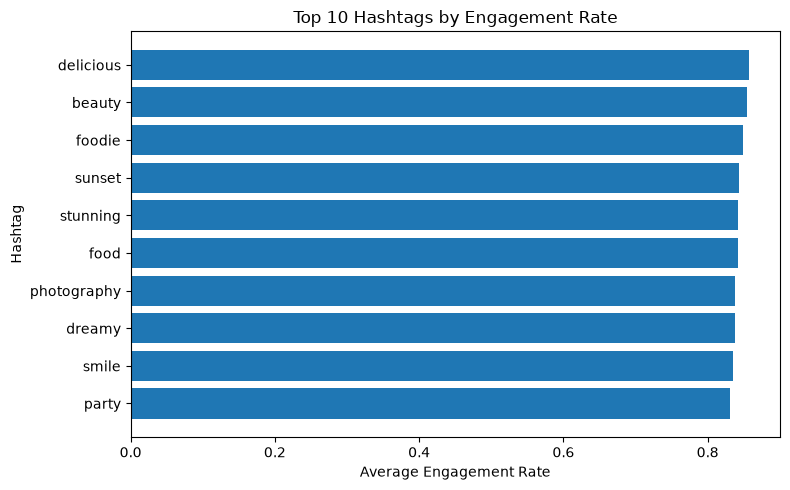

In [92]:
top_tags = tag_perf_10.head(10)

top_tags = top_tags.sort_values(
    "avg_engagement_rate"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_tags["tag text"],
    top_tags["avg_engagement_rate"]
)

plt.xlabel("Average Engagement Rate")
plt.ylabel("Hashtag")
plt.title(
    "Top 10 Hashtags by Engagement Rate"
)

plt.tight_layout()
plt.show()

In [76]:
print("PHOTOS:")
print(photos.columns.tolist())

print("\nLIKES:")
print(likes.columns.tolist())

print("\nCOMMENTS:")
print(comments.columns.tolist())

print("\nPHOTO_TAGS:")
print(photo_tags.columns.tolist())

print("\nTAGS:")
print(tags.columns.tolist())

PHOTOS:
['id', 'image link', 'user ID', 'created dat', 'Insta filter used', 'photo type']

LIKES:
['user ', 'photo', 'created time', 'following or not', 'like type']

COMMENTS:
['id', 'comment', 'User  id', 'Photo id', 'created Timestamp', 'posted date', 'emoji used', 'Hashtags used count']

PHOTO_TAGS:
['photo', 'tag ID', 'user id']

TAGS:
['id', 'tag text', 'created time', 'location']


## 6. Follower/non-follower engagement signal

The likes table records whether the liker was following the account. This is useful as a discovery signal, although it is not the same as measuring follower growth.

,audience,likes,share
0,yes,5853,0.666477
1,no,2929,0.333523


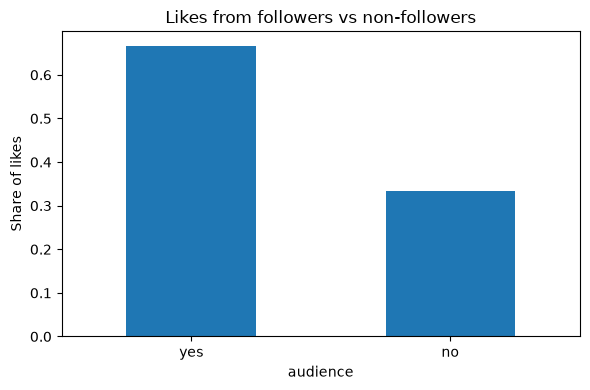

In [77]:
like_status = likes['following or not'].value_counts().rename_axis('audience').reset_index(name='likes')
like_status['share'] = like_status['likes'] / like_status['likes'].sum()
display(like_status)

ax = like_status.set_index('audience')['share'].plot(kind='bar', figsize=(6,4))
ax.set_ylabel('Share of likes')
ax.set_title('Likes from followers vs non-followers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Follower-growth signal

There is no time-varying follower series in this export: every follow relationship has the same timestamp. Therefore, net follower growth, follower growth by post, and follower growth by day cannot be calculated. The available discovery proxy is the share of likes coming from non-followers.

**Observed signal:** 2,929 of 8,782 likes (33.4%) came from non-followers, while 5,853 (66.6%) came from followers. This suggests a meaningful discovery audience, but it should not be interpreted as measured follower acquisition.

## 8. Recommended test calendar for Alfido Tech

Because the export cannot identify a statistically supported best posting time, use a 4-week controlled test. Keep creative quality and posting frequency consistent while rotating time slots.

| Day | Suggested slot (IST) | Content |
|---|---|---|
| Monday | 12:30 PM | Educational carousel / how-to |
| Tuesday | 7:30 PM | Short video / product or tech tip |
| Wednesday | 12:30 PM | Data, case study, or result |
| Thursday | 7:30 PM | Founder/team/behind-the-scenes |
| Friday | 12:30 PM | Practical checklist or industry insight |
| Saturday | 10:30 AM | Community/poll/interactive post |
| Sunday | — | No primary feed post; use Stories/community engagement |

After 4 weeks, compare engagement rate and non-follower reach by slot, then retain the strongest recurring windows.

## 9. Five engagement strategies

1. **Turn expertise into saveable carousels:** use step-by-step guides, checklists, and concise technical explainers.
2. **Increase discovery-oriented video:** publish short demonstrations, before/after workflows, and quick tech tips with a strong first-second hook.
3. **Use conversation prompts:** end posts with one specific question rather than a generic 'thoughts?'.
4. **Build repeatable series:** create weekly themes such as Tech Tip Tuesday, Build Breakdown, or Tool of the Week so followers know what to expect.
5. **Optimize from experiments:** track post time, format, topic, hashtag set, follower/non-follower engagement, saves/shares, and follower change; make one variable change at a time.

## 10. Executive findings from this export

- **257 posts** generated **8,782 likes** and **7,488 comments** (16,270 total recorded engagements).
- Average engagement rate across posts is approximately **83.0%** using reconstructed follower counts.
- Content-type engagement rates are close together; the observed averages are approximately **photo 83.4%**, **video 82.7%**, and **carousel 82.0%**.
- Hashtag differences are modest and should be validated with a larger Alfido Tech-specific dataset.
- **33.4% of likes are from non-followers**, a useful discovery signal, but not a direct follower-growth measure.
- **Posting time cannot be optimized from this export** because all post timestamps are identical.